[2026-05-28 15:23:49 | +00:00:00] 元グラフ生成開始
[2026-05-28 15:23:49 | +00:00:00] 元グラフ生成完了: nodes=100, edges=371
[2026-05-28 15:23:49 | +00:00:00] SPARSIFY_RATIO=0.5, LOCAL_TOP_K=4, K_CORE=2, SPANNER_STRETCH=1.5
[2026-05-28 15:23:49 | +00:00:00] ==============================
[2026-05-28 15:23:49 | +00:00:00] 疎化実行開始
[2026-05-28 15:23:49 | +00:00:00] ==============================
[2026-05-28 15:23:49 | +00:00:00] Original: edges=371, edge_ratio=1.00, avg_degree=7.42, components=1, largest_cc=100
[2026-05-28 15:23:49 | +00:00:00] Random疎化開始 ratio=0.5
[2026-05-28 15:23:49 | +00:00:00] Random疎化完了 edges=185
[2026-05-28 15:23:49 | +00:00:00] Random: edges=185, edge_ratio=0.50, avg_degree=3.70, components=3, largest_cc=98
[2026-05-28 15:23:49 | +00:00:00] Degree疎化開始 ratio=0.5
[2026-05-28 15:23:49 | +00:00:00] Degree疎化完了 edges=185
[2026-05-28 15:23:49 | +00:00:00] Degree: edges=185, edge_ratio=0.50, avg_degree=3.70, components=24, largest_cc=77
[2026-05-28 15:23:49 | +00:00:00] PageRank疎化開始 ratio=

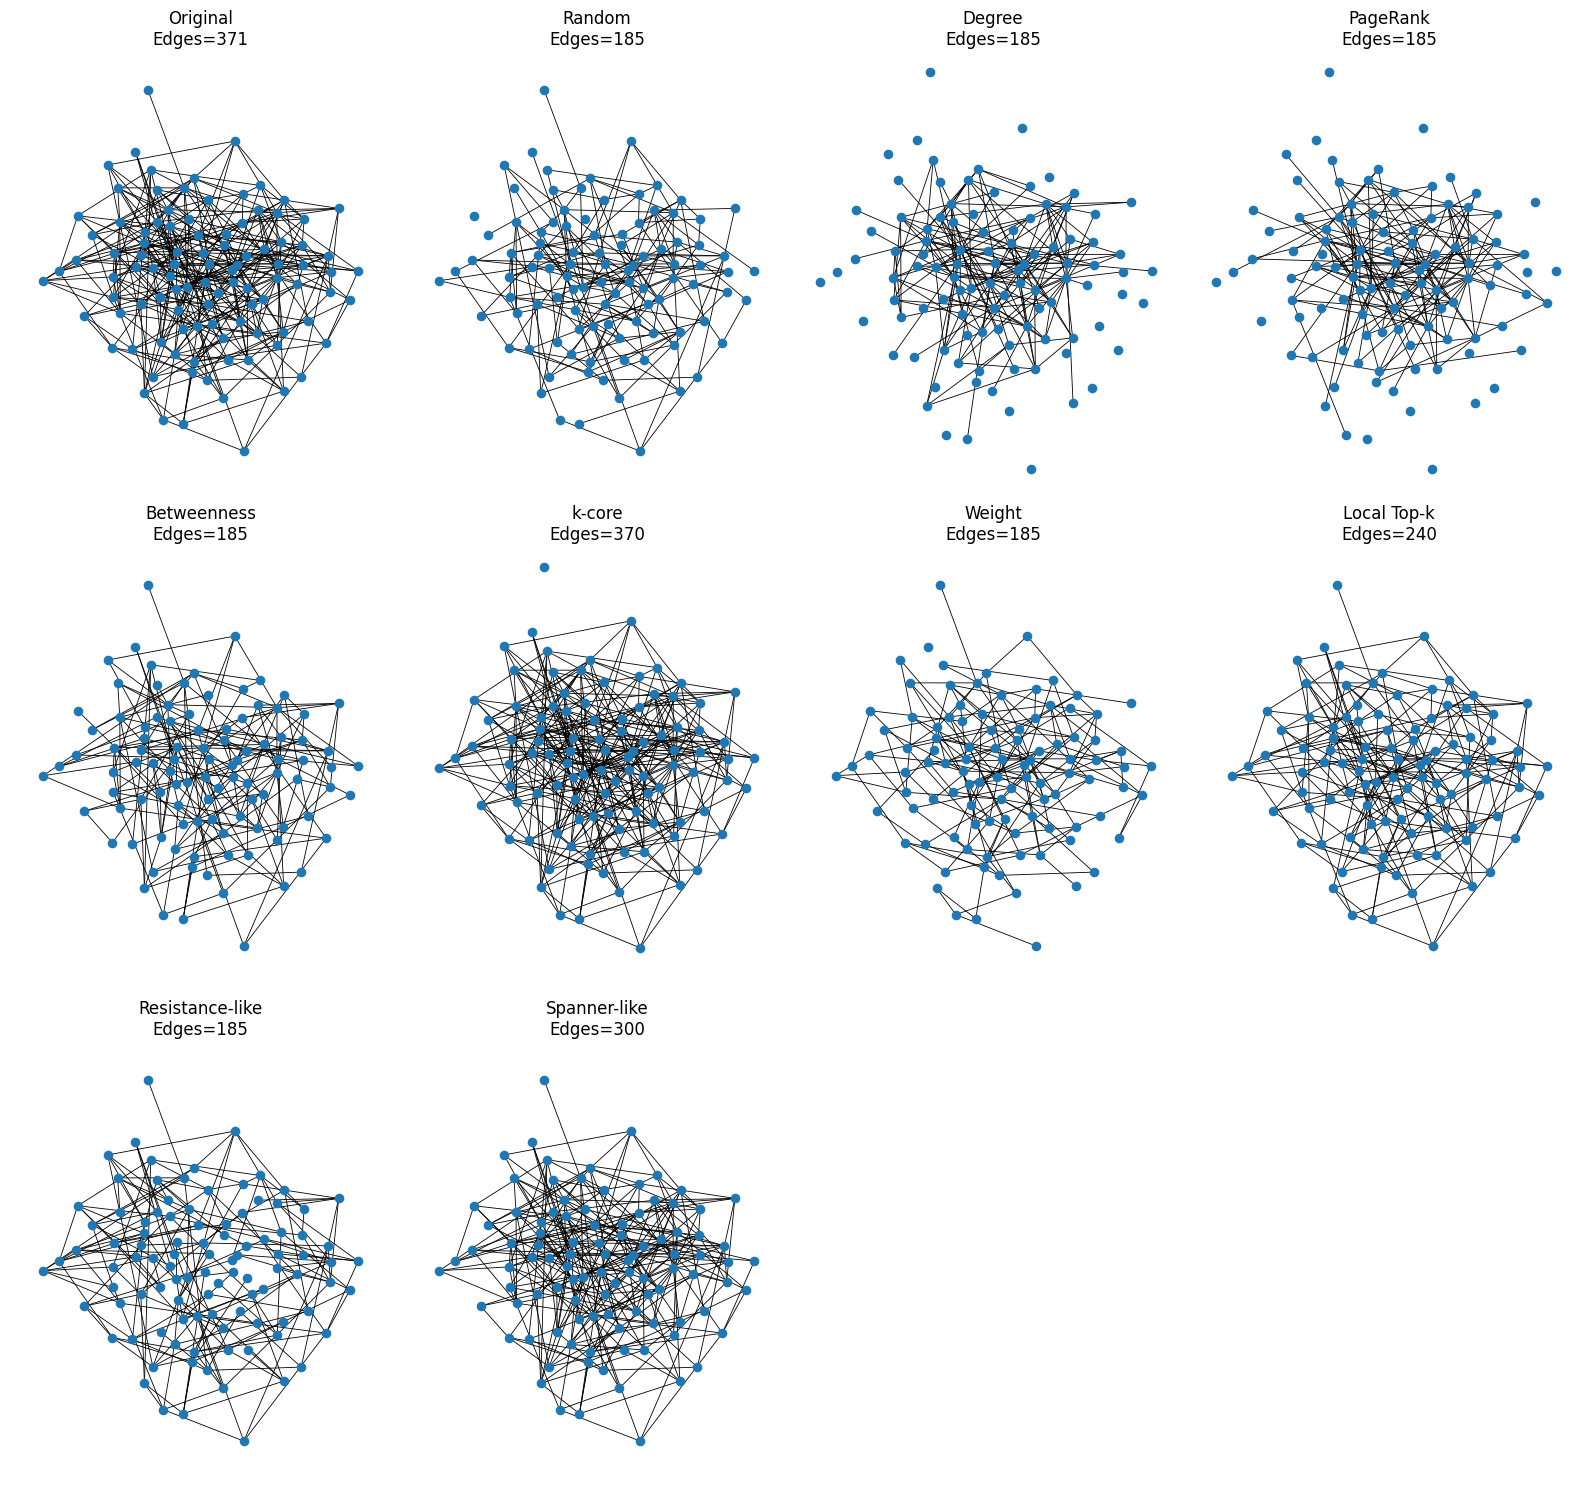

[2026-05-28 15:23:52 | +00:00:02] グラフ描画完了
[2026-05-28 15:23:52 | +00:00:02] 全処理完了


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import time
from datetime import datetime

from networkx.algorithms.approximation import (
    greedy_tsp,
    simulated_annealing_tsp
)

# ============================================================
# グラフ生成パラメータ
# ============================================================

# ノード数
NUM_NODES = 100

# Erdos-Renyi グラフの辺生成確率
#
# 大きいほど:
#   - 元グラフのエッジ数増加
#   - 密なグラフになる
EDGE_PROB = 0.08

# 乱数シード
SEED = 42


# ============================================================
# 疎化パラメータ
# ============================================================

# 多くの疎化手法で使うエッジ保持率
#
# 例:
#   0.3 → 元エッジの30%を保持
#   0.5 → 元エッジの50%を保持
#
# 大きいほど:
#   - エッジ数増加
#   - 連結性改善
#   - TSP性能改善
#   - 計算量増加
SPARSIFY_RATIO = 0.5


# k-core の k
#
# 小さいほど:
#   - 多くのエッジが残る
#   - 疎化が弱い
#
# 大きいほど:
#   - 密な部分だけ残る
#   - 分断されやすい
K_CORE = 2


# Local Top-k の k
#
# 各ノードが保持する近傍エッジ数
#
# 大きいほど:
#   - エッジ数増加
#   - 局所構造保持
LOCAL_TOP_K = 4


# Spanner-like の stretch
#
# 小さいほど:
#   - 最短路保持が厳密
#   - エッジ数増加
#
# 大きいほど:
#   - 疎化が強い
#   - 最短路歪み増加
SPANNER_STRETCH = 1.5


# ============================================================
# TSPパラメータ
# ============================================================

# TSP対象最大ノード数
#
# 大きいほど:
#   - 精度向上
#   - 計算時間増加
MAX_TSP_NODES = 30


# ============================================================
# Simulated Annealing パラメータ
# ============================================================

# 初期温度
SA_TEMP = 100

# 最大反復回数
SA_MAX_ITERATIONS = 300

# 各温度での内部反復
SA_N_INNER = 50

# SA試行回数
SA_TRIALS = 1

# moveタイプ
SA_MOVE = "1-1"


# ============================================================
# 描画設定
# ============================================================

DRAW_GRAPHS = True
DRAW_TSP_PATHS = True
DRAW_TSP_SUMMARY_PLOTS = True


# ============================================================
# プロット配置
# ============================================================

# グラフ表示列数
#
# 4:
#   見やすい
#
# 5:
#   コンパクト
PLOT_COLS = 4


random.seed(SEED)
np.random.seed(SEED)

START_TIME = time.time()


# ============================================================
# ログ関数
# ============================================================

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def elapsed_str():
    sec = int(time.time() - START_TIME)
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"+{h:02d}:{m:02d}:{s:02d}"


def log(msg):
    print(f"[{now_str()} | {elapsed_str()}] {msg}", flush=True)


# ============================================================
# 元グラフ生成
# ============================================================

log("元グラフ生成開始")

G = nx.erdos_renyi_graph(
    n=NUM_NODES,
    p=EDGE_PROB,
    seed=SEED
)

for u, v in G.edges():
    G[u][v]["weight"] = random.random()

ORIGINAL_EDGE_COUNT = G.number_of_edges()

log(
    f"元グラフ生成完了: "
    f"nodes={G.number_of_nodes()}, "
    f"edges={G.number_of_edges()}"
)

log(
    f"SPARSIFY_RATIO={SPARSIFY_RATIO}, "
    f"LOCAL_TOP_K={LOCAL_TOP_K}, "
    f"K_CORE={K_CORE}, "
    f"SPANNER_STRETCH={SPANNER_STRETCH}"
)


# ============================================================
# 共通関数
# ============================================================

def make_graph_from_edges(G, selected_edges):

    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    for u, v in selected_edges:

        if G.has_edge(u, v):
            H.add_edge(u, v, **G[u][v])

        else:
            H.add_edge(u, v, weight=1.0)

    return H


def keep_top_edges_by_score(G, edge_scores, ratio):

    edges = list(G.edges())

    num_keep = max(
        1,
        int(len(edges) * ratio)
    )

    sorted_edges = sorted(
        edges,
        key=lambda e: edge_scores.get(tuple(sorted(e)), 0),
        reverse=True
    )

    return make_graph_from_edges(
        G,
        sorted_edges[:num_keep]
    )


def graph_stats(H):

    avg_degree = (
        sum(dict(H.degree()).values())
        / H.number_of_nodes()
    )

    if H.number_of_edges() > 0:

        components = nx.number_connected_components(H)

        largest_cc_size = len(
            max(
                nx.connected_components(H),
                key=len
            )
        )

    else:

        components = H.number_of_nodes()
        largest_cc_size = 1

    return avg_degree, components, largest_cc_size


def print_graph_info(name, H):

    avg_degree, components, largest_cc_size = graph_stats(H)

    edge_ratio = (
        H.number_of_edges()
        / ORIGINAL_EDGE_COUNT
    )

    log(
        f"{name}: "
        f"edges={H.number_of_edges()}, "
        f"edge_ratio={edge_ratio:.2f}, "
        f"avg_degree={avg_degree:.2f}, "
        f"components={components}, "
        f"largest_cc={largest_cc_size}"
    )


# ============================================================
# 疎化手法
# ============================================================

def random_sparsification(G, ratio):

    log(f"Random疎化開始 ratio={ratio}")

    edges = list(G.edges())

    num_keep = max(
        1,
        int(len(edges) * ratio)
    )

    sampled_edges = random.sample(
        edges,
        num_keep
    )

    H = make_graph_from_edges(
        G,
        sampled_edges
    )

    log(
        f"Random疎化完了 "
        f"edges={H.number_of_edges()}"
    )

    return H


def degree_based_sparsification(G, ratio):

    log(f"Degree疎化開始 ratio={ratio}")

    deg = dict(G.degree())

    edge_scores = {}

    for u, v in G.edges():

        edge_scores[
            tuple(sorted((u, v)))
        ] = deg[u] + deg[v]

    H = keep_top_edges_by_score(
        G,
        edge_scores,
        ratio
    )

    log(
        f"Degree疎化完了 "
        f"edges={H.number_of_edges()}"
    )

    return H


def pagerank_based_sparsification(G, ratio):

    log(f"PageRank疎化開始 ratio={ratio}")

    pr = nx.pagerank(
        G,
        weight="weight"
    )

    edge_scores = {}

    for u, v in G.edges():

        edge_scores[
            tuple(sorted((u, v)))
        ] = pr[u] + pr[v]

    H = keep_top_edges_by_score(
        G,
        edge_scores,
        ratio
    )

    log(
        f"PageRank疎化完了 "
        f"edges={H.number_of_edges()}"
    )

    return H


def edge_betweenness_sparsification(G, ratio):

    log(f"Betweenness疎化開始 ratio={ratio}")

    eb = nx.edge_betweenness_centrality(
        G,
        weight="weight"
    )

    edge_scores = {}

    for e, score in eb.items():

        edge_scores[
            tuple(sorted(e))
        ] = score

    H = keep_top_edges_by_score(
        G,
        edge_scores,
        ratio
    )

    log(
        f"Betweenness疎化完了 "
        f"edges={H.number_of_edges()}"
    )

    return H


def k_core_sparsification(G, k):

    log(f"k-core疎化開始 k={k}")

    core = nx.k_core(G, k=k)

    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    for u, v in core.edges():

        H.add_edge(
            u,
            v,
            **G[u][v]
        )

    log(
        f"k-core疎化完了 "
        f"edges={H.number_of_edges()}"
    )

    return H


def weight_threshold_sparsification(G, ratio):

    log(f"Weight疎化開始 ratio={ratio}")

    edges = list(G.edges(data=True))

    num_keep = max(
        1,
        int(len(edges) * ratio)
    )

    sorted_edges = sorted(
        edges,
        key=lambda x: x[2].get("weight", 0),
        reverse=True
    )

    selected_edges = [
        (u, v)
        for u, v, _
        in sorted_edges[:num_keep]
    ]

    H = make_graph_from_edges(
        G,
        selected_edges
    )

    log(
        f"Weight疎化完了 "
        f"edges={H.number_of_edges()}"
    )

    return H


def local_top_k_sparsification(G, k):

    log(f"Local Top-k疎化開始 k={k}")

    selected_edges = set()

    for node in G.nodes():

        neighbors = list(
            G.neighbors(node)
        )

        scored_neighbors = []

        for nbr in neighbors:

            score = G[node][nbr].get(
                "weight",
                1.0
            )

            scored_neighbors.append(
                (nbr, score)
            )

        scored_neighbors.sort(
            key=lambda x: x[1],
            reverse=True
        )

        for nbr, _ in scored_neighbors[:k]:

            selected_edges.add(
                tuple(sorted((node, nbr)))
            )

    H = make_graph_from_edges(
        G,
        list(selected_edges)
    )

    log(
        f"Local Top-k疎化完了 "
        f"edges={H.number_of_edges()}"
    )

    return H


def effective_resistance_like_sparsification(G, ratio):

    log(f"Resistance-like疎化開始 ratio={ratio}")

    deg = dict(G.degree())

    edge_scores = {}

    for u, v in G.edges():

        score = (
            1 / max(1, deg[u])
            + 1 / max(1, deg[v])
        )

        edge_scores[
            tuple(sorted((u, v)))
        ] = score

    H = keep_top_edges_by_score(
        G,
        edge_scores,
        ratio
    )

    log(
        f"Resistance-like疎化完了 "
        f"edges={H.number_of_edges()}"
    )

    return H


def spanner_like_sparsification(
    G,
    stretch=1.5
):

    log(
        f"Spanner-like疎化開始 "
        f"stretch={stretch}"
    )

    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    edges = list(G.edges(data=True))

    random.shuffle(edges)

    for u, v, data in edges:

        if not nx.has_path(H, u, v):

            H.add_edge(
                u,
                v,
                **data
            )

        else:

            try:

                dist = nx.shortest_path_length(
                    H,
                    u,
                    v,
                    weight="weight"
                )

                direct_weight = data.get(
                    "weight",
                    1.0
                )

                if dist > stretch * direct_weight:

                    H.add_edge(
                        u,
                        v,
                        **data
                    )

            except nx.NetworkXNoPath:

                H.add_edge(
                    u,
                    v,
                    **data
                )

    log(
        f"Spanner-like疎化完了 "
        f"edges={H.number_of_edges()}"
    )

    return H


# ============================================================
# 疎化実行
# ============================================================

log("==============================")
log("疎化実行開始")
log("==============================")

graphs = {}

graphs["Original"] = G
print_graph_info("Original", graphs["Original"])

graphs["Random"] = random_sparsification(
    G,
    SPARSIFY_RATIO
)
print_graph_info("Random", graphs["Random"])

graphs["Degree"] = degree_based_sparsification(
    G,
    SPARSIFY_RATIO
)
print_graph_info("Degree", graphs["Degree"])

graphs["PageRank"] = pagerank_based_sparsification(
    G,
    SPARSIFY_RATIO
)
print_graph_info("PageRank", graphs["PageRank"])

graphs["Betweenness"] = edge_betweenness_sparsification(
    G,
    SPARSIFY_RATIO
)
print_graph_info("Betweenness", graphs["Betweenness"])

graphs["k-core"] = k_core_sparsification(
    G,
    K_CORE
)
print_graph_info("k-core", graphs["k-core"])

graphs["Weight"] = weight_threshold_sparsification(
    G,
    SPARSIFY_RATIO
)
print_graph_info("Weight", graphs["Weight"])

graphs["Local Top-k"] = local_top_k_sparsification(
    G,
    LOCAL_TOP_K
)
print_graph_info("Local Top-k", graphs["Local Top-k"])

graphs["Resistance-like"] = effective_resistance_like_sparsification(
    G,
    SPARSIFY_RATIO
)
print_graph_info("Resistance-like", graphs["Resistance-like"])

graphs["Spanner-like"] = spanner_like_sparsification(
    G,
    SPANNER_STRETCH
)
print_graph_info("Spanner-like", graphs["Spanner-like"])

log("疎化実行完了")


# ============================================================
# グラフ描画
# ============================================================

if DRAW_GRAPHS:

    log("グラフ描画開始")

    pos = nx.spring_layout(
        G,
        seed=SEED
    )

    num_graphs = len(graphs)

    cols = PLOT_COLS

    rows = int(
        np.ceil(num_graphs / cols)
    )

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(16, rows * 5)
    )

    axes = axes.flatten()

    for ax, (name, H) in zip(
        axes,
        graphs.items()
    ):

        nx.draw(
            H,
            pos,
            ax=ax,
            node_size=35,
            width=0.6,
            with_labels=False
        )

        ax.set_title(
            f"{name}\n"
            f"Edges={H.number_of_edges()}"
        )

    for i in range(
        len(graphs),
        len(axes)
    ):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

    log("グラフ描画完了")


log("全処理完了")